In [2]:
pip install librosa

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import librosa
import numpy as np

SAMPLE_RATE = 16000
N_MFCC = 40
MAX_LEN = 300   # time steps

def extract_mfcc(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)

        # Pad or truncate
        if mfcc.shape[1] < MAX_LEN:
            pad_width = MAX_LEN - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0,0),(0,pad_width)))
        else:
            mfcc = mfcc[:, :MAX_LEN]

        return mfcc
    except Exception as e:
        print("Error:", file_path, e)
        return None


In [4]:
import os
import pandas as pd

DATASET_PATH = "Downloads/Audio_Dataset"

data = []

for label_name in ["Normal", "Depression"]:
    class_path = os.path.join(DATASET_PATH, label_name)

    for root, _, files in os.walk(class_path):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)

                mfcc = extract_mfcc(file_path)
                if mfcc is not None:
                    data.append({
                        "mfcc": mfcc,
                        "label": label_name
                    })

df_audio = pd.DataFrame(data)
print(df_audio.head())


                                                mfcc   label
0  [[-760.97565, -756.28796, -700.7534, -584.3927...  Normal
1  [[-758.8275, -755.46173, -700.62946, -598.7965...  Normal
2  [[-737.68964, -682.64435, -585.8421, -511.2647...  Normal
3  [[-751.12415, -738.20465, -636.4585, -524.2427...  Normal
4  [[-721.67065, -735.2104, -691.8538, -569.2906,...  Normal


In [5]:
from sklearn.preprocessing import LabelEncoder

le_audio = LabelEncoder()
df_audio["label_encoded"] = le_audio.fit_transform(df_audio["label"])

class_names_audio = le_audio.classes_
print(class_names_audio)


['Depression' 'Normal']


In [14]:
print(X.shape)      # should be (samples, 1, 40, 300)
print(X.mean(), X.std())


torch.Size([400, 1, 40, 300])
tensor(-1.6423) tensor(36.9743)


In [8]:
!pip install torch

import torch

X = np.stack(df_audio["mfcc"].values)
y = df_audio["label_encoded"].values

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.long)

# Add channel dimension for CNN
X = X.unsqueeze(1)  # (batch, 1, 40, 300)


   ---------------------------------------- 0.0/113.8 MB ? eta -:--:--
   ---------------------------------------- 1.0/113.8 MB 13.2 MB/s eta 0:00:09
    --------------------------------------- 2.6/113.8 MB 8.4 MB/s eta 0:00:14
   - -------------------------------------- 3.9/113.8 MB 7.4 MB/s eta 0:00:15
   - -------------------------------------- 5.2/113.8 MB 7.1 MB/s eta 0:00:16
   -- ------------------------------------- 6.6/113.8 MB 6.8 MB/s eta 0:00:16
   -- ------------------------------------- 7.6/113.8 MB 6.6 MB/s eta 0:00:17
   --- ------------------------------------ 9.2/113.8 MB 6.6 MB/s eta 0:00:16
   --- ------------------------------------ 10.2/113.8 MB 6.5 MB/s eta 0:00:16
   ---- ----------------------------------- 11.5/113.8 MB 6.4 MB/s eta 0:00:16
   ---- ----------------------------------- 12.8/113.8 MB 6.4 MB/s eta 0:00:16
   ---- ----------------------------------- 14.2/113.8 MB 6.4 MB/s eta 0:00:16
   ----- ---------------------------------- 15.2/113.8 MB 6.4 MB/s


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
import torch.nn as nn

class AudioCNNBiLSTM(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.lstm = nn.LSTM(
            input_size=64 * 10,   # will fix dynamically
            hidden_size=128,
            bidirectional=True,
            batch_first=True
        )

        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.cnn(x)   # (B, C, H, W)

        B, C, H, W = x.shape
        x = x.permute(0, 3, 1, 2)      # (B, W, C, H)
        x = x.reshape(B, W, C * H)     # (B, W, features)

        if x.shape[2] != self.lstm.input_size:
            raise ValueError(f"LSTM input mismatch: {x.shape[2]}")

        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])


In [19]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
 
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=16)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_audio = AudioCNNBiLSTM(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_audio.parameters(), lr=3e-5)

for epoch in range(50):
    model_audio.train()
    preds, true = [], []

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()

        out = model_audio(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()

        preds.extend(out.argmax(1).cpu().numpy())
        true.extend(yb.cpu().numpy())

    acc = accuracy_score(true, preds)
    print(f"Epoch {epoch+1} | Train Acc: {acc:.4f}")

Epoch 1 | Train Acc: 0.5000
Epoch 2 | Train Acc: 0.5000
Epoch 3 | Train Acc: 0.5000
Epoch 4 | Train Acc: 0.4875
Epoch 5 | Train Acc: 0.5000
Epoch 6 | Train Acc: 0.5000
Epoch 7 | Train Acc: 0.4625
Epoch 8 | Train Acc: 0.4750
Epoch 9 | Train Acc: 0.4500
Epoch 10 | Train Acc: 0.4750
Epoch 11 | Train Acc: 0.4750
Epoch 12 | Train Acc: 0.4875
Epoch 13 | Train Acc: 0.4750
Epoch 14 | Train Acc: 0.4750
Epoch 15 | Train Acc: 0.5000
Epoch 16 | Train Acc: 0.4562
Epoch 17 | Train Acc: 0.5000
Epoch 18 | Train Acc: 0.5000
Epoch 19 | Train Acc: 0.4562
Epoch 20 | Train Acc: 0.5000
Epoch 21 | Train Acc: 0.4688
Epoch 22 | Train Acc: 0.5000
Epoch 23 | Train Acc: 0.5000
Epoch 24 | Train Acc: 0.4750
Epoch 25 | Train Acc: 0.5000
Epoch 26 | Train Acc: 0.4500
Epoch 27 | Train Acc: 0.5000
Epoch 28 | Train Acc: 0.4562
Epoch 29 | Train Acc: 0.5000
Epoch 30 | Train Acc: 0.5000
Epoch 31 | Train Acc: 0.4875
Epoch 32 | Train Acc: 0.5000
Epoch 33 | Train Acc: 0.4750
Epoch 34 | Train Acc: 0.4750
Epoch 35 | Train Acc: 0

In [20]:
from sklearn.metrics import classification_report

model_audio.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for xb, yb in val_loader:
        xb = xb.to(device)
        out = model_audio(xb)
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_true.extend(yb.numpy())

print(
    classification_report(
        all_true,
        all_preds,
        target_names=class_names_audio
    )
)


              precision    recall  f1-score   support

  Depression       0.50      1.00      0.67        40
      Normal       0.00      0.00      0.00        40

    accuracy                           0.50        80
   macro avg       0.25      0.50      0.33        80
weighted avg       0.25      0.50      0.33        80



C:\Users\taluk\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\taluk\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\taluk\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

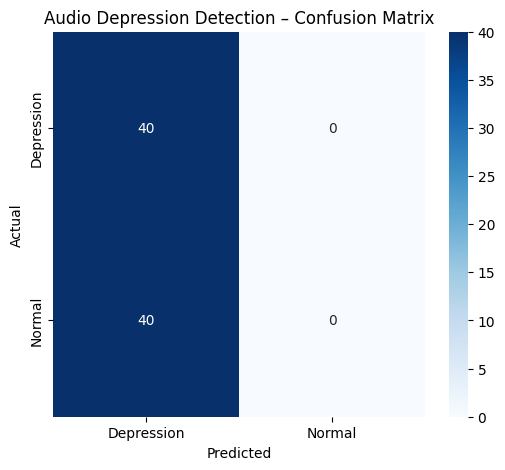

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names_audio,
            yticklabels=class_names_audio,
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Audio Depression Detection – Confusion Matrix")
plt.savefig("audio_confusion_matrix.png", dpi=300)
plt.show()
